In [ ]:
!python -m pip install --upgrade pip
!pip install tensorflow-hub

In [6]:
pip show tensorflow-hub

Name: tensorflow-hub
Version: 0.16.1
Summary: TensorFlow Hub is a library to foster the publication, discovery, and consumption of reusable parts of machine learning models.
Home-page: https://github.com/tensorflow/hub
Author: Google LLC
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\deepa\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: numpy, protobuf, tf-keras
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np

import cv2

import PIL.Image as Image
import os

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow .keras.models import Sequential

In [66]:
import tf_keras


IMAGE_SHAPE = (128, 128)
classifier = tf_keras.Sequential([
    hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-128-classification/2", input_shape=IMAGE_SHAPE+(3,))
])

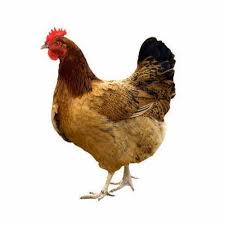

In [32]:
image=Image.open("C://Users//deepa//Desktop//hen.jpeg")
image

In [27]:
image=cv2.imread((str)("C://Users//deepa//Desktop//hen.jpeg"))
img=cv2.resize(img,(128,128))

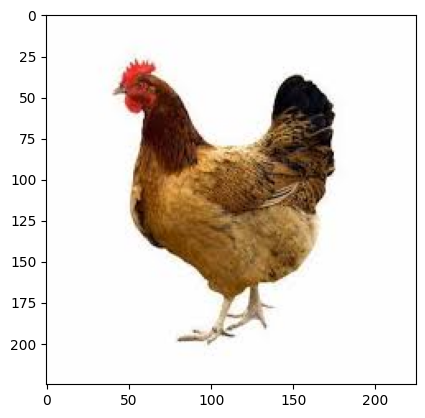

In [26]:
import matplotlib.pyplot as plt
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

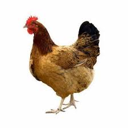

In [35]:
image=Image.open("C://Users//deepa//Desktop//hen.jpeg").resize([128,128])
image

In [36]:
image=np.array(image)/255.0

In [37]:
image

array([[[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843]],

       [[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843]],

       [[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        ...,
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843]],

       ...,

       [[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0

In [38]:
image[np.newaxis, ...].shape

(1, 128, 128, 3)

In [40]:
result=classifier.predict(image[np.newaxis,...])
result.shape

1/1 [==============================] - 1s 959ms/step


(1, 1001)

In [41]:
ind=np.argmax(result)
ind

9

In [52]:
from pathlib import Path
path=Path("datasets/flower_photos")

In [53]:
if path.exists():
    print(f"The path {path} exists.")
else:
    print(f"The path {path} does not exist.")

The path datasets\flower_photos exists.


In [62]:
flower_image={
    'roses':list(path.glob('roses/*')),
    'tulips':list(path.glob('tulips/*')),
    'sunflowers':list(path.glob('sunflowers/*')),
    'daisy':list(path.glob('daisy/*')),
    'dandelion':list(path.glob('dandelion/*')),
}

In [63]:
flower_image['sunflowers']

[WindowsPath('datasets/flower_photos/sunflowers/1008566138_6927679c8a.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/1022552002_2b93faf9e7_n.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/1022552036_67d33d5bd8_n.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/10386503264_e05387e1f7_m.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/10386522775_4f8c616999_m.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/10386525005_fd0b7d6c55_n.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/10386525695_2c38fea555_n.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/10386540106_1431e73086_m.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/10386540696_0a95ee53a8_n.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/10386702973_e74a34c806_n.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/1043442695_4556c4c13d_n.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/1044296388_912143e1d4.jpg'),
 WindowsPath('datasets/flower_photos/sunflowers/1

In [64]:
flower_label={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4
}

In [102]:
x,y=[],[]
for flower_name,flower_images in flower_image.items():
    for image in flower_images:
        img=cv2.imread(str(image))
        img=cv2.resize(img,([224,224]))
        x.append(img)
        y.append(flower_label[flower_name])

In [103]:
x=np.array(x)
y=np.array(y)

In [87]:
x=x/255.0

In [104]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=24)

In [105]:
x_test[0]

array([[[ 2, 34, 69],
        [ 2, 34, 69],
        [ 2, 35, 68],
        ...,
        [32, 92, 86],
        [31, 91, 85],
        [30, 90, 84]],

       [[ 2, 34, 69],
        [ 2, 35, 68],
        [ 2, 35, 68],
        ...,
        [30, 90, 82],
        [29, 89, 83],
        [28, 88, 82]],

       [[ 2, 35, 68],
        [ 2, 35, 68],
        [ 2, 35, 68],
        ...,
        [29, 89, 81],
        [28, 88, 80],
        [28, 88, 80]],

       ...,

       [[ 1, 25, 54],
        [ 1, 25, 55],
        [ 0, 26, 55],
        ...,
        [ 1, 35, 41],
        [ 1, 35, 41],
        [ 1, 35, 41]],

       [[ 0, 25, 55],
        [ 0, 25, 55],
        [ 0, 26, 56],
        ...,
        [ 0, 35, 41],
        [ 1, 35, 41],
        [ 1, 35, 41]],

       [[ 0, 25, 55],
        [ 0, 26, 56],
        [ 0, 26, 56],
        ...,
        [ 0, 34, 40],
        [ 0, 34, 40],
        [ 0, 34, 40]]], dtype=uint8)

In [77]:
image_label=[]
with open("ImageNetLabels.txt","r") as f:
    image_labels=f.read().splitlines()

In [79]:
image_labels[:10]

['background',
 'tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen']

In [82]:
feature_ext="https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

In [84]:
pretrained=hub.KerasLayer(
    feature_ext,input_shape=(224,224,3),trainable=False)

In [92]:
flower_num=5

model=tf_keras.Sequential([
    pretrained,
    tf_keras.layers.Dense(flower_num)
])
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_14 (KerasLayer  (None, 1280)              2257984   
 )                                                               
                                                                 
 dense_1 (Dense)             (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [106]:
model.compile(
    optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])
model.fit(x_train,y_train,epochs=15)

Epoch 1/15



92/92 [==============================] - 56s 553ms/step - loss: 1.4713 - accuracy: 0.3917
Epoch 2/15
92/92 [==============================] - 49s 536ms/step - loss: 1.1883 - accuracy: 0.5395
Epoch 3/15
92/92 [==============================] - 48s 516ms/step - loss: 1.0943 - accuracy: 0.5851
Epoch 4/15
92/92 [==============================] - 53s 578ms/step - loss: 1.0294 - accuracy: 0.6090
Epoch 5/15
92/92 [==============================] - 52s 567ms/step - loss: 0.9787 - accuracy: 0.6376
Epoch 6/15
92/92 [==============================] - 55s 600ms/step - loss: 0.9457 - accuracy: 0.6516
Epoch 7/15
92/92 [==============================] - 55s 596ms/step - loss: 0.9172 - accuracy: 0.6563
Epoch 8/15
92/92 [==============================] - 50s 539ms/step - loss: 0.8871 - accuracy: 0.6676
Epoch 9/15
92/92 [==============================] - 48s 525ms/step - loss: 0.8546 - accuracy: 0.6870
Epoch 10/15
92/92 [==============================] - 50s 541ms/step - loss: 0.8350 - accuracy: 0.6907
